In [ ]:
# ── 타이타닉 matplotlib ─────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

In [ ]:
TITANIC_URL = (
  'https://raw.githubusercontent.com/'
  'datasciencedojo/datasets/master/titanic.csv'
)
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


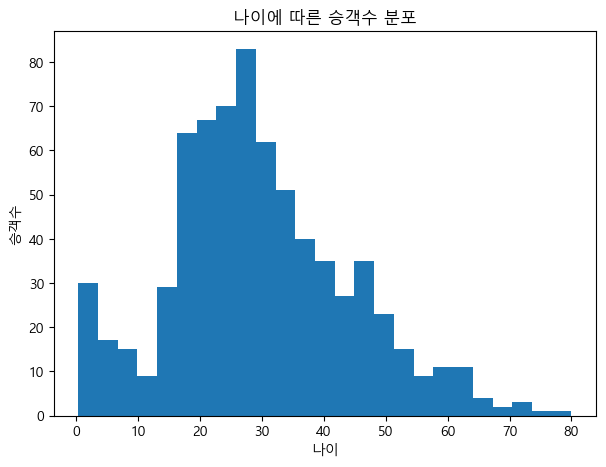

In [28]:
# B1. 나이 히스토그램 (bins=25, 제목·축 레이블 포함)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(titanic['Age'], bins=25)

ax.set_title('나이에 따른 승객수 분포')
ax.set_xlabel('나이')
ax.set_ylabel('승객수')
plt.savefig('histogram.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

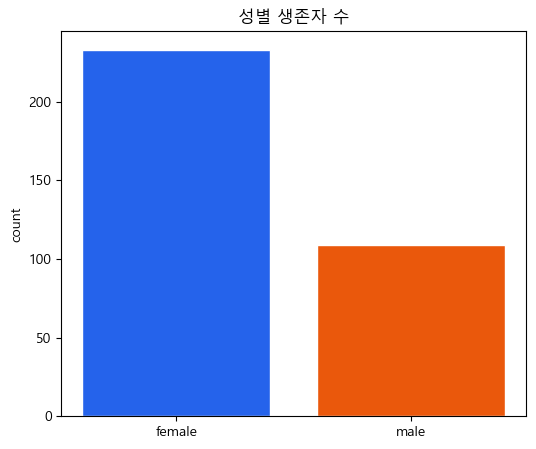

In [29]:
# B2. 성별 생존자 수 막대그래프
survived = titanic[titanic['Survived'] == 1]
gender_count = survived['Sex'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(gender_count.index, gender_count.values, 
       color=['#2563eb','#ea580c'],
       edgecolor='white')
ax.set_title('성별 생존자 수')
ax.set_ylabel('count')
plt.savefig('bar.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

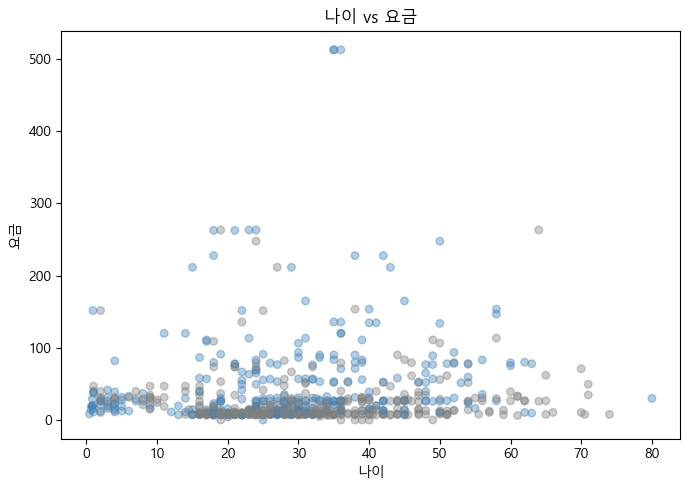

In [30]:
# B3. 나이 vs 요금 산점도 (생존여부 색상 구분)

colors = titanic['Survived'].map({0:'gray', 1:'steelblue'})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(titanic['Age'], titanic['Fare'],
           c=colors, 
           alpha=0.4, 
           s=30)
ax.set_title('나이 vs 요금')
ax.set_xlabel('나이')
ax.set_ylabel('요금')
plt.tight_layout()
plt.savefig('scatter.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

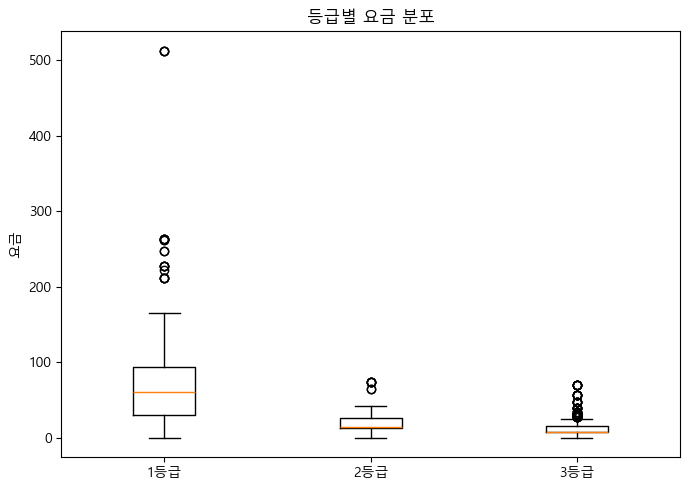

In [31]:
# B4. 등급별 요금 박스플롯
data = [titanic[titanic['Pclass']==c]['Fare'].dropna()
        for c in [1, 2, 3]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data,
           tick_labels=['1등급', '2등급', '3등급'])
ax.set_title('등급별 요금 분포')
ax.set_ylabel('요금')
plt.tight_layout()
plt.savefig('boxplot.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

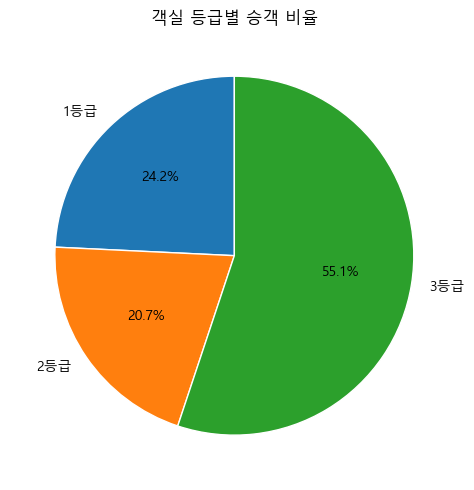

In [32]:
# B5. 탑승항(Embarked)별 승객 비율 파이차트
class_counts = titanic['Pclass'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(class_counts.values,
       labels=['1등급', '2등급', '3등급'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('객실 등급별 승객 비율')
plt.tight_layout()
plt.savefig('pie.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

# → 각 차트 PNG로 저장

In [33]:
# ── IMDB plotly ──────────────────────────────────
imdb = pd.read_csv('./imdb_top_1000.csv')
imdb.head(3)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [ ]:
# B6. IMDB_Rating 히스토그램 (marginal='box' 포함)
# B7. 투표 수 vs 평점 scatter (hover_name=영화 제목)
# B8. B7 차트를 HTML로 저장